## LOAD THE DATASET

In [1]:
import pandas as pd


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
os.getcwd()

'C:\\Users\\USER\\Downloads'

In [3]:
import os
os.chdir(r"C:\Users\USER\Downloads")
print(os.getcwd())
import pandas as pd
df = pd.read_excel(r"C:\Users\USER\Downloads\aug_train.xlsx")
df.head()


C:\Users\USER\Downloads


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


## CHECK FOR NULL & DUPLICATED VALUES

In [4]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [5]:
df["gender"].fillna("Unknown", inplace=True)

df["major_discipline"].fillna("Unknown", inplace=True)
df["company_size"].fillna("Unknown", inplace=True)

df["company_type"].fillna("Unknown", inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_13280\222522060.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gender"].fillna("Unknown", inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_13280\222522060.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [6]:
df["education_level"].fillna(df["education_level"].mode()[0], inplace=True)

df["enrolled_university"].fillna(df["enrolled_university"].mode()[0], inplace=True)

df["last_new_job"].fillna(df["last_new_job"].mode()[0], inplace=True)

df["experience"].fillna(df["experience"].mode()[0], inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_13280\2330001622.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["education_level"].fillna(df["education_level"].mode()[0], inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_13280\2330001622.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  19158 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     19158 non-null  object 
 6   education_level         19158 non-null  object 
 7   major_discipline        19158 non-null  object 
 8   experience              19158 non-null  object 
 9   company_size            19158 non-null  object 
 10  company_type            19158 non-null  object 
 11  last_new_job            19158 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  int64  
dtypes: float64(1), int64(3), object(10)
me

In [13]:
df["experience"].unique()

array(['>20', 15, 5, '<1', 11, 13, 7, 17, 2, 16, 1, 4, 10, 14, 18, 19, 12,
       3, 6, 9, 8, 20], dtype=object)

In [15]:
df["experience"] = df["experience"].replace({
    "<1": 0,
    ">20": 21
})

C:\Users\USER\AppData\Local\Temp\ipykernel_13960\2176226695.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["experience"] = df["experience"].replace({


In [18]:
df["experience"] = df["experience"].astype(float)

In [19]:
df["experience"].fillna(df["experience"].median(), inplace=True)
df["last_new_job"].unique()
df["last_new_job"] = df["last_new_job"].replace({
    "never": 0,
    ">4": 5
})

C:\Users\USER\AppData\Local\Temp\ipykernel_13960\3155514512.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["experience"].fillna(df["experience"].median(), inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_13960\3155514512.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["last_ne

In [20]:
df["last_new_job"] = df["last_new_job"].astype(float)

In [21]:
df["last_new_job"].fillna(df["last_new_job"].median(), inplace=True)
df[["experience", "last_new_job"]].head()
df["company_size"] = df["company_size"].replace({
    "Oct-49": "10-49"
})

C:\Users\USER\AppData\Local\Temp\ipykernel_13960\2786386018.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["last_new_job"].fillna(df["last_new_job"].median(), inplace=True)


In [23]:
df.dtypes

enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                float64
company_size               object
company_type               object
last_new_job              float64
training_hours              int64
target                      int64
dtype: object

## EDA

In [25]:
## NUMERICAL DISTRIBUTION

In [26]:
df.describe()

,enrollee_id,city_development_index,experience,last_new_job,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,10.137123,1.978338,65.366896,0.249348
std,9616.292592,0.123362,6.795143,1.663502,60.058462,0.432647
min,1.000000,0.448000,0.000000,0.000000,1.000000,0.000000
25%,8554.250000,0.740000,4.000000,1.000000,23.000000,0.000000
50%,16982.500000,0.903000,9.000000,1.000000,47.000000,0.000000
75%,25169.750000,0.920000,16.000000,3.000000,88.000000,0.000000
max,33380.000000,0.949000,21.000000,5.000000,336.000000,1.000000


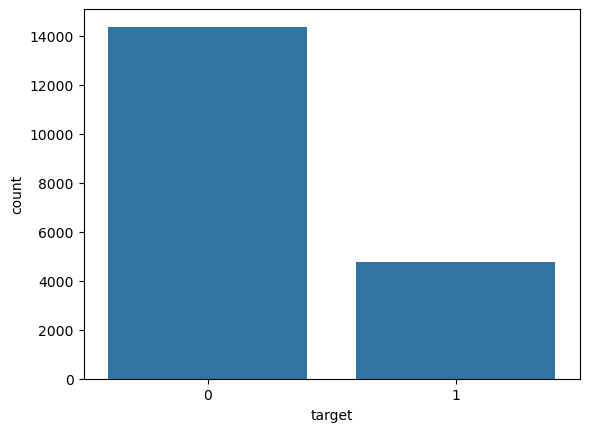

In [26]:
#Target Distribution
sns.countplot(x='target', data=df)
plt.show()

#### C. Categorical Features

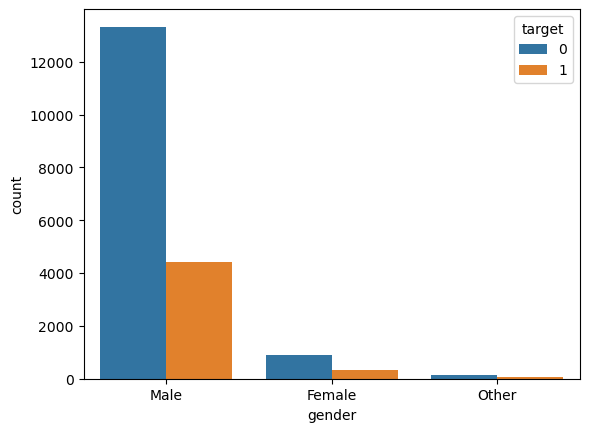

target,0,1
gender,,
Female,73.667205,26.332795
Male,75.176265,24.823735
Other,73.821990,26.178010


In [27]:
#Gender vs Retention
sns.countplot(x='gender', hue='target', data=df)
plt.show()
#lets calculate the percentage to have a better insight
pd.crosstab(
    df['gender'],
    df['target'],
    normalize='index'
)*100
#Gender-wise analysis indicates that male employees are slightly more likely to stay with the organization than female employee


# Before presenting this finding and reaching final conclusion, check how many employees belong to each education category:


In [12]:
df['education_level'].value_counts()

education_level
Graduate          12058
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

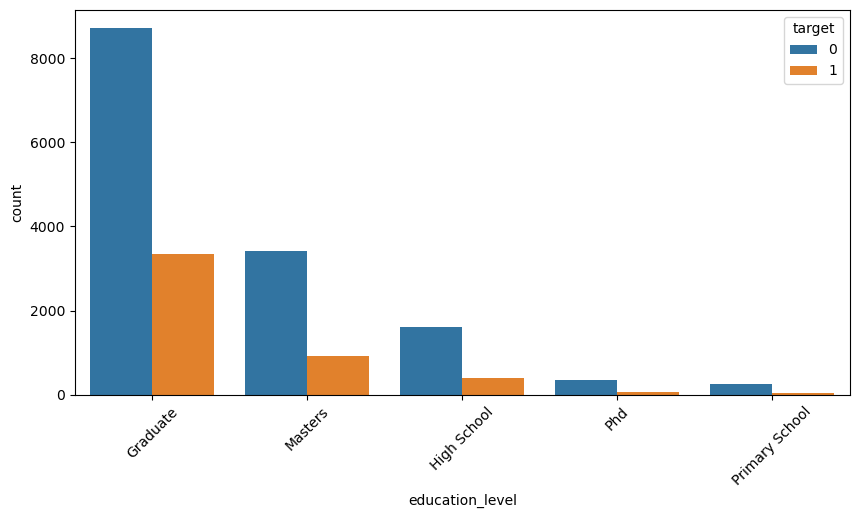

target,0,1
education_level,,
Graduate,72.225908,27.774092
High School,80.466039,19.533961
Masters,78.559963,21.440037
Phd,85.990338,14.009662
Primary School,86.688312,13.311688


In [28]:
#Education vs Retention
plt.figure(figsize=(10,5))
sns.countplot(x='education_level', hue='target', data=df)
plt.xticks(rotation=45)
plt.show()
#lets analyze it by finding the percentage:
pd.crosstab(
    df['education_level'],
    df['target'],
    normalize='index'
)*100

#Education level appears to influence employee retention. Graduate employees, who constitute the majority of the workforce (12,058 employees), exhibit the highest attrition rate of 27.77%. In contrast, employees with Master's and PhD qualifications show better retention rates. This suggests that graduate-level employees may be more actively seeking career advancement opportunities and are therefore more likely to change jobs.

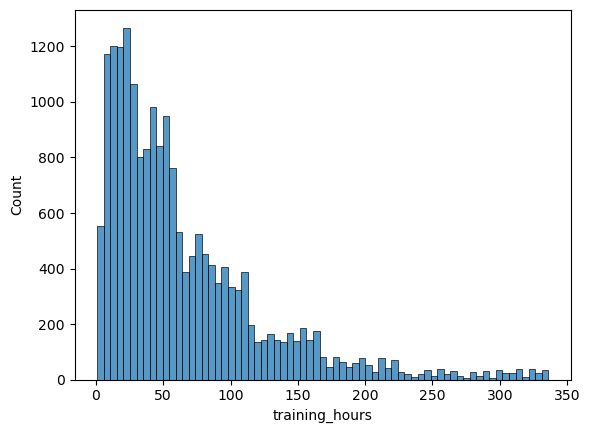

In [14]:
#Experience Distribution
sns.histplot(df['training_hours'])
plt.show()

In [15]:

#Training_hours is positively (right) skewed.
#Most employees have low training hours (roughly between 10 and 60 hours).
#As training hours increase, the number of employees decreases.
#Very few employees have training hours above 200.
#There are some extreme values up to around 330 hours, which may be considered outliers.

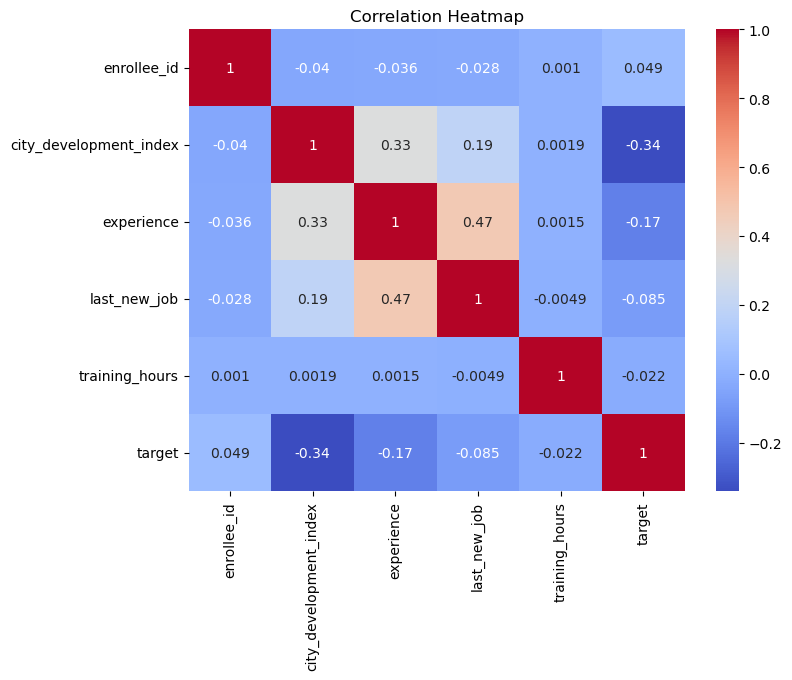

In [30]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
#THE ABOVE STATEMENTS CAN BE SURELY CONCLUDED BY THIS DATA
df['training_hours'].describe()

count    19158.000000
mean        65.366896
std         60.058462
min          1.000000
25%         23.000000
50%         47.000000
75%         88.000000
max        336.000000
Name: training_hours, dtype: float64

## For Employee Retention Prediction project, boxplots are mainly used to:

Detect outliers.
Compare numerical variables with the target (Retention/Attrition).

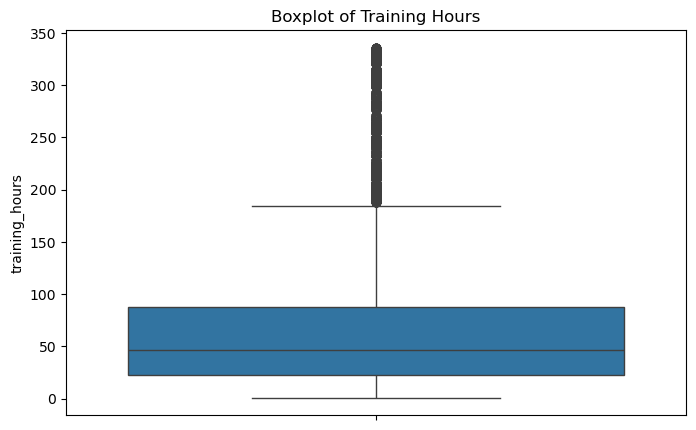

In [27]:
#BOXPLOT FOR TRAINING HOURS OUTLIERS
plt.figure(figsize=(8,5))

sns.boxplot(y=df['training_hours'])

plt.title("Boxplot of Training Hours")
plt.show()

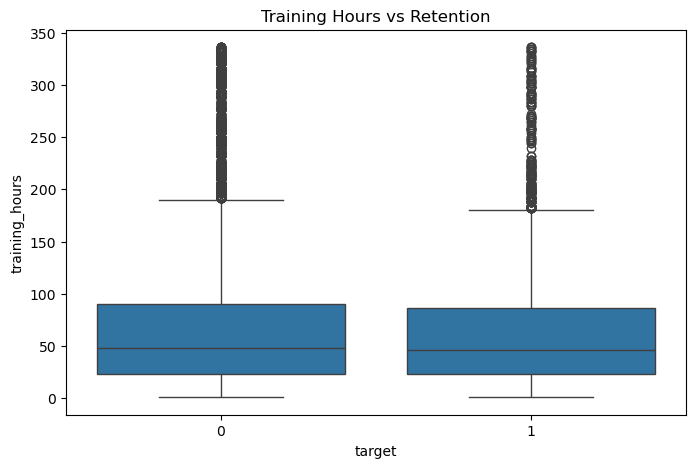

In [29]:
#Training Hours vs Retention
plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='training_hours',
    data=df
)

plt.title("Training Hours vs Retention")
plt.show()

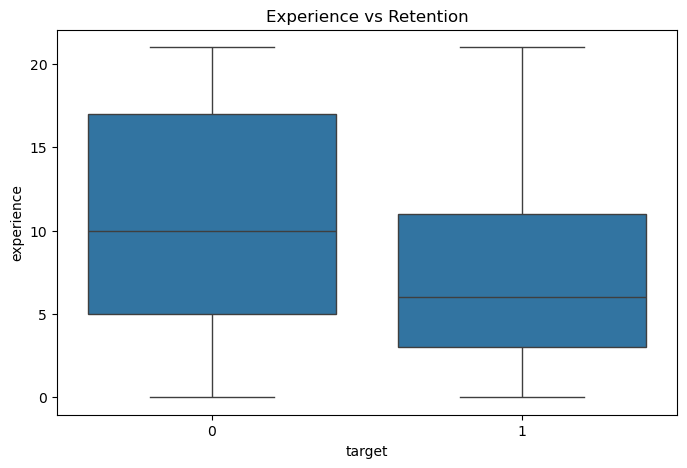

In [31]:
df['experience'] = df['experience'].replace({
    '>20':21,
    '<1':0
})

df['experience'] = pd.to_numeric(df['experience'])
plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='experience',
    data=df
)

plt.title("Experience vs Retention")
plt.show()

#


## Boxplots for All Numerical Columns


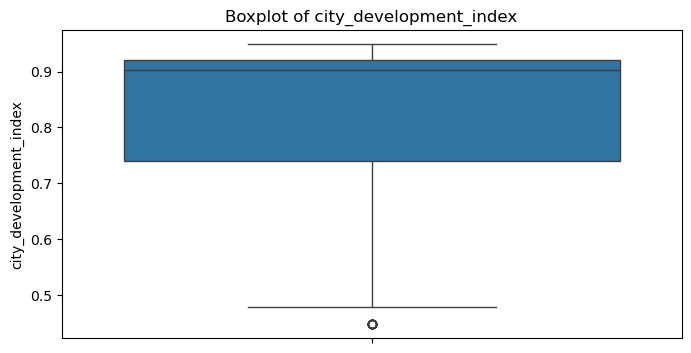

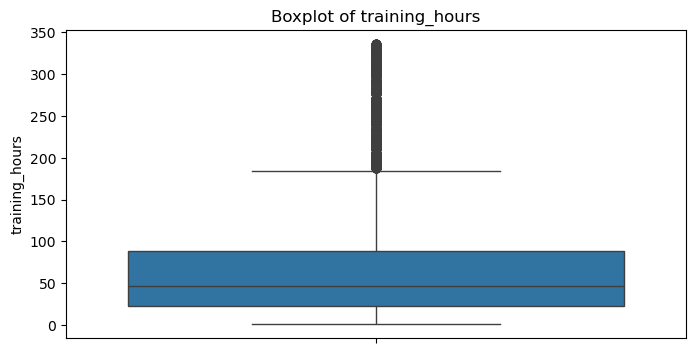

In [32]:
num_cols = [
    'city_development_index',
    'training_hours'
]

for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(y=df[col])
    
    plt.title(f'Boxplot of {col}')
    
    plt.show()

### Identify Outliers Numerically

In [33]:
Q1 = df['training_hours'].quantile(0.25)
Q3 = df['training_hours'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

print(lower)
print(upper)

-74.5
185.5


Most employees have training hours within the normal range. However, a small group of employees have training hours exceeding 185.5 hours, making them outliers. These employees may have participated in specialized training programs, leadership development initiatives, or intensive skill-building activities.

In [73]:
## CHECK THE NUMBER OF OUTLIERS

In [34]:
outliers = df[df['training_hours'] > 185.5]

print("Number of outliers:", len(outliers))

Number of outliers: 984


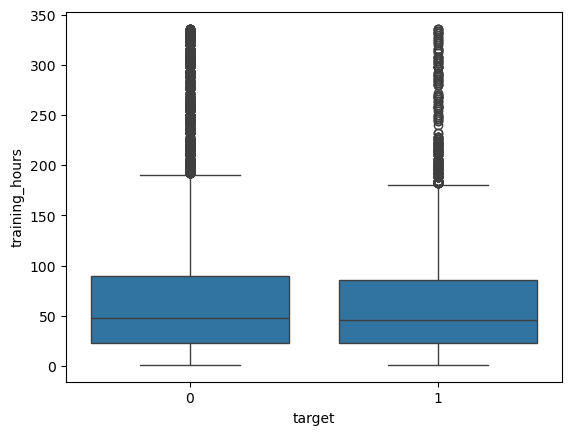

In [35]:
sns.boxplot(x='target', y='training_hours', data=df)
plt.show()

## Encoding

In [38]:
df= df.drop("enrollee_id", axis=1)

KeyError: "['enrollee_id'] not found in axis"

In [35]:
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(exclude="object").columns

print(cat_cols)
print(num_cols)

Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'company_size', 'company_type'],
      dtype='object')
Index(['city_development_index', 'experience', 'last_new_job',
       'training_hours', 'target'],
      dtype='object')


In [36]:
cat_cols = df.select_dtypes(include="object").columns

num_cols = df.drop("target", axis=1).select_dtypes(exclude="object").columns

print(cat_cols)
print(num_cols)

Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'company_size', 'company_type'],
      dtype='object')
Index(['city_development_index', 'experience', 'last_new_job',
       'training_hours'],
      dtype='object')


In [37]:
df= pd.get_dummies(df, columns=cat_cols, drop_first=True)

##TRAIN-TEST SPLIT

In [44]:
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('target', axis=1)

y = df_encoded['target']
print(X.shape)
print(y.shape)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

(19158, 153)
(19158,)


## MODEL BUILDING


In [ ]:
## LOGISTIC REGRESSION

In [82]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
## EVALUATE
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))


Accuracy: 0.7766179540709812
Accuracy: 0.7766179540709812
[[2668  209]
 [ 647  308]]
              precision    recall  f1-score   support

           0       0.80      0.93      0.86      2877
           1       0.60      0.32      0.42       955

    accuracy                           0.78      3832
   macro avg       0.70      0.62      0.64      3832
weighted avg       0.75      0.78      0.75      3832

Precision: 0.5957446808510638
Recall: 0.3225130890052356
F1 Score: 0.41847826086956524


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## DECISION TREE

In [74]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
## EVALUATE
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7072025052192067
[[2270  607]
 [ 515  440]]
              precision    recall  f1-score   support

           0       0.82      0.79      0.80      2877
           1       0.42      0.46      0.44       955

    accuracy                           0.71      3832
   macro avg       0.62      0.62      0.62      3832
weighted avg       0.72      0.71      0.71      3832



## RANDOM FOREST

In [76]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
## EVALUATE
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7734864300626305
[[2572  305]
 [ 563  392]]
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      2877
           1       0.56      0.41      0.47       955

    accuracy                           0.77      3832
   macro avg       0.69      0.65      0.67      3832
weighted avg       0.76      0.77      0.76      3832



## AdaBoost

In [77]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
## EVALUATE
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print(confusion_matrix(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

Accuracy: 0.7747912317327766
[[2682  195]
 [ 668  287]]
              precision    recall  f1-score   support

           0       0.80      0.93      0.86      2877
           1       0.60      0.30      0.40       955

    accuracy                           0.77      3832
   macro avg       0.70      0.62      0.63      3832
weighted avg       0.75      0.77      0.75      3832



## Model Comparison Table : TO FIND THE BEST MODEL

In [84]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    'Model':['Logistic Regression',
             'Decision Tree',
             'Random Forest',
             'AdaBoost'],

    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_ada)
    ],

    'Precision':[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_dt),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_ada)
    ],

    'Recall':[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_ada)
    ],

    'F1 Score':[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_ada)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.776618   0.595745  0.322513  0.418478
1        Decision Tree  0.707203   0.420248  0.460733  0.439560
2        Random Forest  0.773486   0.562410  0.410471  0.474576
3             AdaBoost  0.774791   0.595436  0.300524  0.399443


## CHOOSE THE BEST MODEL

Four machine learning models were evaluated for Employee Retention Prediction: Logistic Regression, Decision Tree, Random Forest, and AdaBoost. Although Logistic Regression achieved the highest accuracy (77.66%), Random Forest demonstrated the best overall balance between Precision and Recall, resulting in the highest F1 Score (47.46%).

Since employee retention prediction requires correctly identifying employees who are likely to leave, F1 Score was considered a key evaluation metric. Based on overall performance,## Random Forest was selected as the final model for this project.


In [89]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
## EVALUATE
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.7734864300626305
[[2572  305]
 [ 563  392]]
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      2877
           1       0.56      0.41      0.47       955

    accuracy                           0.77      3832
   macro avg       0.69      0.65      0.67      3832
weighted avg       0.76      0.77      0.76      3832



## INSIGHTS

In [90]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,enrollee_id,0.175612
4,training_hours,0.164706
2,experience,0.113570
1,city_development_index,0.102152
3,last_new_job,0.058304
68,city_city_21,0.045710
144,company_size_50-99,0.026174
131,enrolled_university_no_enrollment,0.019728
129,relevent_experience_No relevent experience,0.019065
133,education_level_Masters,0.017575


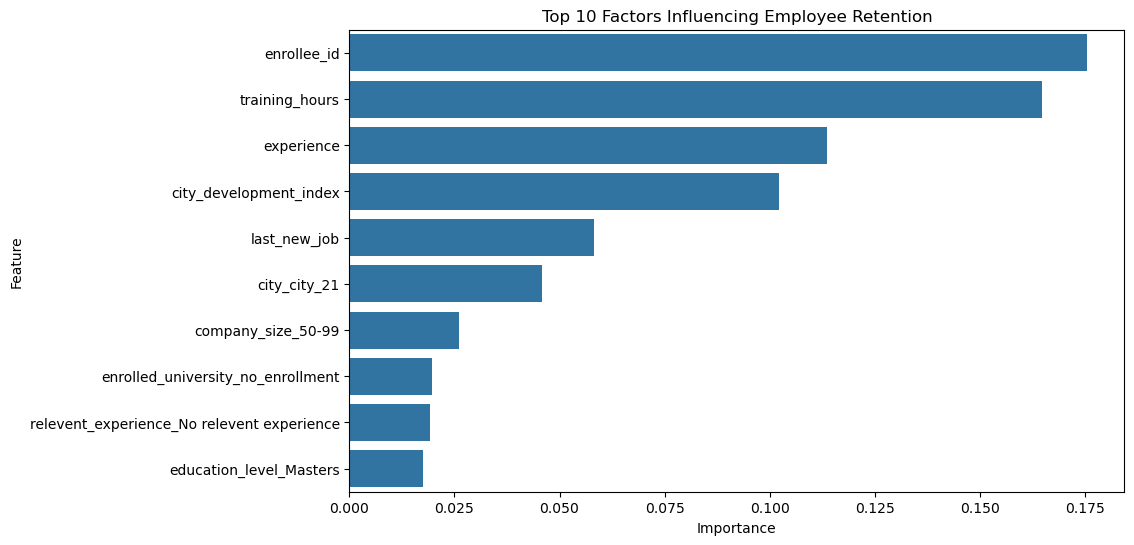

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Factors Influencing Employee Retention')
plt.show()


# Final Model Improvement Section

## Enhancements Added
1. SMOTE to handle class imbalance.
2. StandardScaler for Logistic Regression.
3. Tuned Random Forest with balanced class weights.
4. Gradient Boosting model.
5. Comprehensive evaluation using Accuracy, Precision, Recall and F1 Score.
6. Feature Importance analysis.
7. Model comparison table for report inclusion.


In [ ]:

# ===============================
# CLASS IMBALANCE HANDLING
# ===============================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original Training Shape:", X_train.shape)
print("After SMOTE:", X_train_smote.shape)


In [ ]:

# ===============================
# FEATURE SCALING
# ===============================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)


In [ ]:

# ===============================
# IMPROVED MODELS
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

lr_final = LogisticRegression(max_iter=2000)

rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

gb_final = GradientBoostingClassifier(random_state=42)

lr_final.fit(X_train_scaled, y_train_smote)
rf_final.fit(X_train_smote, y_train_smote)
gb_final.fit(X_train_smote, y_train_smote)


In [ ]:

# ===============================
# MODEL EVALUATION
# ===============================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

models = {
    "Logistic Regression": (lr_final, X_test_scaled),
    "Random Forest": (rf_final, X_test),
    "Gradient Boosting": (gb_final, X_test)
}

for model_name, (model, X_eval) in models.items():
    pred = model.predict(X_eval)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1 Score", ascending=False)

print(results_df)


In [ ]:

# ===============================
# FEATURE IMPORTANCE
# ===============================
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_final.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

feature_importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.tight_layout()
plt.show()
